#BoW bag of Words


# Step 1: Tokenize the data, remove stop words and perform stemming or lemmatization.

In [9]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 7.9 MB/s eta 0:00:13
    --------------------------------------- 2.4/101.7 MB 6.4 MB/s eta 0:00:16
   - -------------------------------------- 3.9/101.7 MB 6.1 MB/s eta 0:00:17
   -- ------------------------------------- 5.5/101.7 MB 7.0 MB/s eta 0:00:14
   -- ------------------------------------- 7.3/101.7 MB 7.0 MB/s eta 0:00:14
   --- ------------------------------------ 8.9/101.7 MB 7.2 MB/s eta 0:00:13
   ---- ----------------------------------- 10.2/101.7 MB 6.9 MB/s eta 0:00:14
   ---- ----------------------------------- 12.1/101.7 MB 7.2 MB/s eta 0:00:13
   ----- ---------------------------------- 13.9/101.7 MB 7.4 MB/s eta 0:00:12
   ------ --------------------------------- 16.3/101.7 MB 7.8 MB/s eta 0:00:11
   ------- -------------------------------- 18.6/101.7 MB 8.1 MB/s eta 0:0

In [4]:
import pandas as pd
import nltk
import nltk
# Download the 'stopwords' dataset
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from timeit import default_timer as timer
import matplotlib.pyplot as plt


[nltk_data] Downloading package stopwords to C:\Users\HP
[nltk_data]     840\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\HP
[nltk_data]     840\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\HP
[nltk_data]     840\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
df = pd.read_csv('../data.csv')
df.head()

,content,label
0,I like the game and is have funny legend and s...,Positif
1,"I just retrieved my acc, great customer servic...",Positif
2,good game,Positif
3,it's best,Positif
4,good,Positif


In [3]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Membersihkan karakter non-alphabet dan konversi ke lowercase
    # Menggunakan string mentah karena kita memproses per baris (content)
    sent = re.sub('[^a-zA-Z]', ' ', str(text))
    sent = sent.lower()
    
    # 2. Tokenisasi sederhana dengan split
    words = sent.split()
    
    # 3. Lemmatization & Stopword Removal
    # Menghapus kata yang ada di daftar stopword dan mengubah ke bentuk dasar
    tokens = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # Mengembalikan dalam bentuk string yang digabung kembali (sesuai logika corpus Anda)
    return ' '.join(tokens)

# Mengubah variabel sentence ke dalam df['tokens'] menggunakan apply
df['tokens'] = df['content'].apply(preprocess_text)

# Jika Anda tetap membutuhkan list 'corpus' untuk pemrosesan lanjut (seperti Word2Vec/TF-IDF)
corpus = df['tokens'].tolist()

print(df['tokens'].head())

0    like game funny legend cool skin tone type blu...
1    retrieved acc great customer service really he...
2                                            good game
3                                                 best
4                                                 good
Name: tokens, dtype: object


# Step 2: List all unique words

In [4]:
print("Corpus:", corpus)

Corpus: ['like game funny legend cool skin tone type blueberry muffin want brainrot going let house want boy mobile store want easy home eye one watching video call shirt get work ok please lucky block please let trade value yeah uo', 'retrieved acc great customer service really helped alot', 'good game', 'best', 'good', 'good', 'moontoon kocak', 'wonderful experience app internet connection play offline ip overall amazing game highly recommend love lot', 'fuunnn play friend duo', 'good', 'game fun sometimes getting nerve cause player cannot play good really love game recommendation moonton hok copying hero gonna release new hero make sure hok player creator know', 'ok jks', 'mlbb best top', 'best game', 'l like', 'goooooooooood', 'much fun play friend', 'good game', 'great', 'make stress game favorite game game best ever', 'nice game', 'nice', 'best game world', 'fun absolutely recommended', 'matchmaking system getting better many event give interesting reward continuous improvement h

In [5]:
# Finding unique words
all_words = []
for sentence in corpus:
    for word in sentence.split():
        all_words.append(word)

unique_words = list(set(all_words))
print("Unique words:", unique_words)

Unique words: ['use', 'recently', 'supposed', 'guy', 'pathetic', 'bout', 'ppl', 'lagging', 'good', 'house', 'ty', 'contact', 'esu', 'great', 'history', 'ng', 'helped', 'area', 'improve', 'deliberately', 'pre', 'user', 'screen', 'experiment', 'couple', 'op', 'bible', 'story', 'without', 'remove', 'country', 'else', 'old', 'hating', 'gone', 'cheat', 'significant', 'btw', 'logged', 'happy', 'rating', 'rank', 'focus', 'got', 'mid', 'violation', 'seimei', 'budge', 'legend', 'middle', 'must', 'clean', 'goodbye', 'literally', 'metro', 'bar', 'ace', 'awareness', 'way', 'punya', 'became', 'defiet', 'unacceptable', 'towards', 'freaking', 'click', 'x', 'complicated', 'started', 'top', 'little', 'new', 'ever', 'flip', 'mach', 'glory', 'reported', 'target', 'beginner', 'planned', 'prioritize', 'useless', 'actually', 'discus', 'fav', 'stop', 'release', 'honestly', 'popular', 'engineered', 'assess', 'unfair', 'crazy', 'ui', 'mobile', 'brain', 'carry', 'darksytem', 'reiterating', 'fine', 'um', 'really

#Step 3: Create a dictionary with mapping of words to a number. This should now be sorted on frequency of occurrence in descending order.

Finding unique words and their frequencies

In [6]:
all_words = []
for sentence in corpus:
    for word in sentence.split():
        all_words.append(word)

word_frequencies = Counter(all_words)

# Print the word counts
print("Word Frequencies:", word_frequencies)

# Sorting words by frequency (descending)
sorted_words = sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)

# Creating the dictionary mapping words to numbers
word_to_number = {}
for i, (word, frequency) in enumerate(sorted_words):
    word_to_number[word] = i + 1  # Assign numbers starting from 1

print("Word to Number Mapping (Sorted by Frequency):", word_to_number)


Word Frequencies: Counter({'game': 142, 'good': 47, 'player': 38, 'like': 36, 'matchmaking': 34, 'play': 32, 'hero': 25, 'make': 25, 'system': 24, 'team': 24, 'please': 23, 'skin': 22, 'match': 21, 'fun': 18, 'moonton': 18, 'want': 17, 'really': 17, 'give': 17, 'teammate': 17, 'get': 15, 'love': 15, 'many': 14, 'fix': 14, 'dark': 14, 'kagura': 14, 'mobile': 13, 'one': 13, 'star': 13, 'unfair': 13, 'legend': 12, 'bad': 12, 'always': 12, 'best': 11, 'still': 11, 'even': 11, 'mlbb': 10, 'skill': 10, 'rank': 10, 'u': 10, 'account': 10, 'enemy': 10, 'feel': 10, 'experience': 9, 'worst': 9, 'solo': 9, 'playing': 9, 'great': 8, 'much': 8, 'nice': 8, 'keep': 8, 'pls': 8, 'people': 8, 'making': 8, 'work': 7, 'recommend': 7, 'lot': 7, 'friend': 7, 'new': 7, 'ever': 7, 'character': 7, 'got': 7, 'ranked': 7, 'hope': 7, 'diamond': 7, 'time': 7, 'mythic': 7, 'win': 7, 'back': 7, 'sometimes': 6, 'know': 6, 'better': 6, 'use': 6, 'lag': 6, 'honor': 6, 'phone': 6, 'would': 6, 'problem': 6, 'improve': 6

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000)
bow_matrix = cv.fit_transform(corpus).toarray()

bow_df = pd.DataFrame(bow_matrix, columns=cv.get_feature_names_out())
print(f"BoW Matrix Shape: {bow_df.shape}")
bow_df.head()

BoW Matrix Shape: (174, 910)


,abandon,able,absolutely,abt,abuse,acc,account,ace,action,actually,...,yeah,year,yet,yin,youtube,yss,yung,zero,zilong,zin
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
x = df['content'].fillna('').astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])
print(f"\nLabel classes: {label_encoder.classes_}")

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Train: {len(xtrain)}, Test: {len(xtest)}")



Label classes: ['Negatif' 'Netral' 'Positif']
Train: 139, Test: 35


In [12]:
cv_bow = CountVectorizer(max_features=5000)

start = timer()
xtrain_bow = cv_bow.fit_transform(xtrain).toarray()
print(f"BoW train shape: {xtrain_bow.shape} | time: {timer()-start:.2f}s")

start = timer()
xtest_bow = cv_bow.transform(xtest).toarray()
print(f"BoW test shape : {xtest_bow.shape} | time: {timer()-start:.2f}s")

BoW train shape: (139, 1009) | time: 0.04s
BoW test shape : (35, 1009) | time: 0.00s


In [13]:
svm_clf  = LinearSVC()
lr_clf   = LogisticRegression(max_iter=1000)
nb_clf   = MultinomialNB()
xgb_clf  = XGBClassifier(eval_metric='mlogloss', verbosity=0)
rfc_clf  = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt',
                                   min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=42)

def evaluate_model(model, xtest, ytest):
    y_pred     = model.predict(xtest)
    accuracy   = accuracy_score(ytest, y_pred)
    precision  = precision_score(ytest, y_pred, average='weighted', zero_division=0)
    recall     = recall_score(ytest, y_pred, average='weighted', zero_division=0)
    f1         = f1_score(ytest, y_pred, average='weighted', zero_division=0)
    report     = classification_report(ytest, y_pred, zero_division=0)
    cm         = confusion_matrix(ytest, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [14]:
start = timer(); svm_bow  = svm_clf.fit(xtrain_bow, ytrain);  print(f"SVM trained  : {timer()-start:.2f}s")
start = timer(); lr_bow   = lr_clf.fit(xtrain_bow, ytrain);   print(f"LR trained   : {timer()-start:.2f}s")
start = timer(); nb_bow   = nb_clf.fit(xtrain_bow, ytrain);   print(f"NB trained   : {timer()-start:.2f}s")
start = timer(); xgb_bow  = xgb_clf.fit(xtrain_bow, ytrain);  print(f"XGB trained  : {timer()-start:.2f}s")
start = timer(); rfc_bow  = rfc_clf.fit(xtrain_bow, ytrain);  print(f"RFC trained  : {timer()-start:.2f}s")

_, acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm   = evaluate_model(svm_bow,  xtest_bow, ytest)
_, acc_lr,  prec_lr,  rec_lr,  f1_lr,  rep_lr,  cm_lr    = evaluate_model(lr_bow,   xtest_bow, ytest)
_, acc_nb,  prec_nb,  rec_nb,  f1_nb,  rep_nb,  cm_nb    = evaluate_model(nb_bow,   xtest_bow, ytest)
_, acc_xgb, prec_xgb, rec_xgb, f1_xgb, rep_xgb, cm_xgb  = evaluate_model(xgb_bow,  xtest_bow, ytest)
_, acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc   = evaluate_model(rfc_bow,  xtest_bow, ytest)

SVM trained  : 0.04s
LR trained   : 0.05s
NB trained   : 0.00s
XGB trained  : 0.22s
RFC trained  : 0.16s


In [15]:
models = {
    'LinearSVM'         : (acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm),
    'LogisticRegression': (acc_lr,  prec_lr,  rec_lr,  f1_lr,  rep_lr,  cm_lr),
    'NaiveBayes'        : (acc_nb,  prec_nb,  rec_nb,  f1_nb,  rep_nb,  cm_nb),
    'XGBoost'           : (acc_xgb, prec_xgb, rec_xgb, f1_xgb, rep_xgb, cm_xgb),
    'RandomForest'      : (acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc),
}

for name, (acc, prec, rec, f1, rep, cm) in models.items():
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.2f}")
    print(f"  Precision: {prec:.2f}")
    print(f"  Recall   : {rec:.2f}")
    print(f"  F1 Score : {f1:.2f}")
    print("  Classification Report:")
    print(rep)
    print("  Confusion Matrix:")
    print(cm)


  LinearSVM
  Accuracy : 0.77
  Precision: 0.87
  Recall   : 0.77
  F1 Score : 0.77
  Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         7
           1       1.00      0.50      0.67        14
           2       0.93      0.93      0.93        14

    accuracy                           0.77        35
   macro avg       0.81      0.81      0.75        35
weighted avg       0.87      0.77      0.77        35

  Confusion Matrix:
[[ 7  0  0]
 [ 6  7  1]
 [ 1  0 13]]

  LogisticRegression
  Accuracy : 0.74
  Precision: 0.83
  Recall   : 0.74
  F1 Score : 0.73
  Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70         7
           1       1.00      0.43      0.60        14
           2       0.81      0.93      0.87        14

    accuracy                           0.74        35
   macro avg       0.78      0.79      0.72        35
weighte

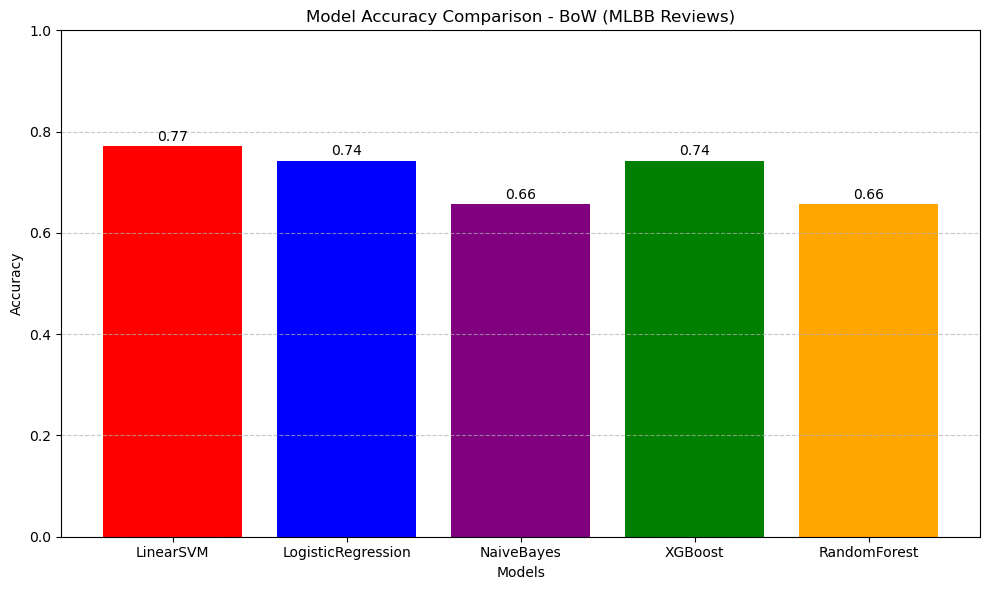

In [19]:
model_names = list(models.keys())
model_accs  = [v[0] for v in models.values()]

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accs, color=['red', 'blue', 'purple', 'green', 'orange'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison - BoW (MLBB Reviews)")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(model_accs):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()